## **NOTE: Code intended for SLEAP 1.3.4**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

# Add sleap packages
import sys
sys.path.insert(0, '/ceph/apps/ubuntu-24/packages/SLEAP/2025-09-30/lib/python3.7/site-packages')
import sleap

# QC - sleap inference

#### Metadata

In [2]:
# --- Paths ---
CEPH_BASE = Path('/ceph/aeon/aeon/data/raw/AEON3/abcEphysPilot01')
SESSION = '2026-04-14T141851Z_calibrateBeforeAprilExperiments'
SESSION_DIR = CEPH_BASE / SESSION
TIMESTAMP = "2026-04-14T14-00-00"

PREDICTIONS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/predictions')
MODELS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/models')
LABELS_DIR = Path('/nfs/nhome/live/zsus/aeon_sleap/abcEphysPilot01/labels')

# --- Cameras ---
CAMERAS = ['CameraEast', 'CameraNorth', 'CameraSouth', 'CameraWest', 'CameraNest', 'CameraTop']
NODE_ORDER = ["corner_1", "corner_2", "corner_3", "corner_4"]

# --- Quality Threshold ---
CONF_THRESH = 0.7

## --- Examples ---
# video_path = SESSION_DIR / 'CameraTop' / 'CameraTop_2026-04-14T14-00-00.avi'
# pred_path = PREDICTIONS_DIR / 'CameraTop_CameraTop_2026-04-14T14-00-00.slp'

In [3]:
slp_paths = {cam: next(PREDICTIONS_DIR.glob(f"{cam}_*.slp")) for cam in CAMERAS}
labels_by_cam = {cam: sleap.load_file(str(p)) for cam, p in slp_paths.items()}

for cam, p in slp_paths.items():
    print(f"{cam}: {p.name}")

CameraEast: CameraEast_CameraEast_2026-04-14T14-00-00.slp
CameraNorth: CameraNorth_CameraNorth_2026-04-14T14-00-00.slp
CameraSouth: CameraSouth_CameraSouth_2026-04-14T14-00-00.slp
CameraWest: CameraWest_CameraWest_2026-04-14T14-00-00.slp
CameraNest: CameraNest_CameraNest_2026-04-14T14-00-00.slp
CameraTop: CameraTop_CameraTop_2026-04-14T14-00-00.slp


### Load data from cameras

In [4]:
# helpers for video reading
def build_video_path(camera: str) -> Path:
    return SESSION_DIR / camera / f"{camera}_{TIMESTAMP}.avi"

def read_frame(video_path, frame_idx: int) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        cap.release()
        raise FileNotFoundError(f"Could not open video: {video_path}")
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(frame_idx))
    ok, frame = cap.read()
    cap.release()
    if not ok or frame is None:
        raise RuntimeError(f"Could not read frame {frame_idx} from: {video_path}")
    return frame  # BGR

def bgr_to_rgb(img_bgr: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

## Organize in df

In [5]:
def extract_points_and_frames(labels, camera, node_order=NODE_ORDER):
    """
    Returns:
      points_df: one row per (frame, corner)
      frames_df: one row per frame with summary stats
      meta: dict with video info
    """
    v = labels.videos[0]
    T = int(v.shape[0])

    rows = []
    for lf in labels.labeled_frames:
        t = int(lf.frame_idx)
        if len(lf.instances) < 1:
            continue
        inst = lf.instances[0]

        for node_name, pt in zip(inst.skeleton.node_names, inst.points):
            rows.append({
                "camera": camera,
                "frame_idx": t,
                "node_name": node_name,
                "x": float(pt.x) if pt.visible else None,
                "y": float(pt.y) if pt.visible else None,
                "score": float(pt.score) if hasattr(pt, 'score') else None,
                "visible": bool(pt.visible),
                "complete": bool(pt.complete),
            })

    points_df = pd.DataFrame(rows)
    if points_df.empty:
        frames_df = pd.DataFrame(columns=[
            "camera","frame_idx","n_points","min_score","mean_score","all4_present","all4_ge_thresh"
        ])
        meta = {"video_shape": tuple(v.shape), "video_T": T, "video_filename": str(v.filename)}
        return points_df, frames_df, meta
    
    # Force node order consistency
    points_df["node_name"] = pd.Categorical(points_df["node_name"], categories=node_order, ordered=True)

    # Frame-level summary
    g = points_df.groupby(["camera", "frame_idx"])
    frames_df = g["score"].agg(["min", "mean", "count"]).reset_index()
    frames_df = frames_df.rename(columns={"min": "min_score", "mean": "mean_score", "count": "n_points"})

    # all4_present
    n_unique_nodes = g["node_name"].nunique().reset_index(name="n_unique_nodes")
    frames_df = frames_df.merge(n_unique_nodes, on=["camera","frame_idx"], how="left")
    frames_df["all4_present"] = frames_df["n_unique_nodes"] == 4

    # all4_ge_thresh
    frames_df["all4_ge_thresh"] = frames_df["all4_present"] & (frames_df["min_score"] >= CONF_THRESH)

    meta = {"video_shape": tuple(v.shape), "video_T": T, "video_filename": str(v.filename)}
    return points_df, frames_df, meta

In [6]:
points_all = []
frames_all = []
meta_by_cam = {}

for cam, labels in labels_by_cam.items():
    p_df, f_df, meta = extract_points_and_frames(labels, cam)
    points_all.append(p_df)
    frames_all.append(f_df)
    meta_by_cam[cam] = meta

points_df = pd.concat(points_all, ignore_index=True)
frames_df = pd.concat(frames_all, ignore_index=True)

display(frames_df.head())

,camera,frame_idx,min_score,mean_score,n_points,n_unique_nodes,all4_present,all4_ge_thresh
0,CameraEast,1814,0.293575,0.336064,2,2,False,False
1,CameraEast,1815,0.225215,0.368754,3,3,False,False
2,CameraEast,1816,0.238419,0.389957,3,3,False,False
3,CameraEast,1817,0.205726,0.394330,3,3,False,False
4,CameraEast,1818,0.469426,0.517253,3,3,False,False


In [7]:
summary_rows = []
for cam in CAMERAS:
    meta = meta_by_cam[cam]
    f = frames_df[frames_df["camera"] == cam]
    p = points_df[points_df["camera"] == cam]

    n_pred_frames = int(f["frame_idx"].nunique()) if not f.empty else 0
    frac_pred_frames = n_pred_frames / meta["video_T"] if meta["video_T"] else np.nan

    summary_rows.append({
        "camera": cam,
        "video_T": meta["video_T"],
        "video_shape": meta["video_shape"],
        "n_pred_frames": n_pred_frames,
        "frac_frames_with_predictions": frac_pred_frames,
        "frac_frames_all4_present": float(f["all4_present"].mean()) if len(f) else np.nan,
        "frac_frames_all4_ge_thresh": float(f["all4_ge_thresh"].mean()) if len(f) else np.nan,
        "mean_min_corner_score": float(f["min_score"].mean()) if len(f) else np.nan,
        "median_min_corner_score": float(f["min_score"].median()) if len(f) else np.nan,
        "mean_point_score": float(p["score"].mean()) if len(p) else np.nan,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,camera,video_T,video_shape,n_pred_frames,frac_frames_with_predictions,frac_frames_all4_present,frac_frames_all4_ge_thresh,mean_min_corner_score,median_min_corner_score,mean_point_score
0,CameraEast,29584,"(29584, 1080, 1440, 1)",9968,0.336939,0.738764,0.446730,0.672407,0.710007,0.815406
1,CameraNorth,29584,"(29584, 1080, 1440, 1)",9696,0.327745,0.735974,0.548886,0.716866,0.837779,0.849272
2,CameraSouth,29584,"(29584, 1080, 1440, 1)",10530,0.355936,0.690693,0.187749,0.525971,0.542338,0.686430
3,CameraWest,29584,"(29584, 1080, 1440, 1)",10260,0.346809,0.738889,0.309747,0.568654,0.610396,0.738696
4,CameraNest,29584,"(29584, 540, 720, 1)",587,0.019842,0.548552,0.507666,0.766467,0.849781,0.896570
5,CameraTop,29584,"(29584, 1080, 1440, 1)",19719,0.666543,0.827780,0.639231,0.763151,0.847787,0.893983


# Visual QC

### Labelling over video length

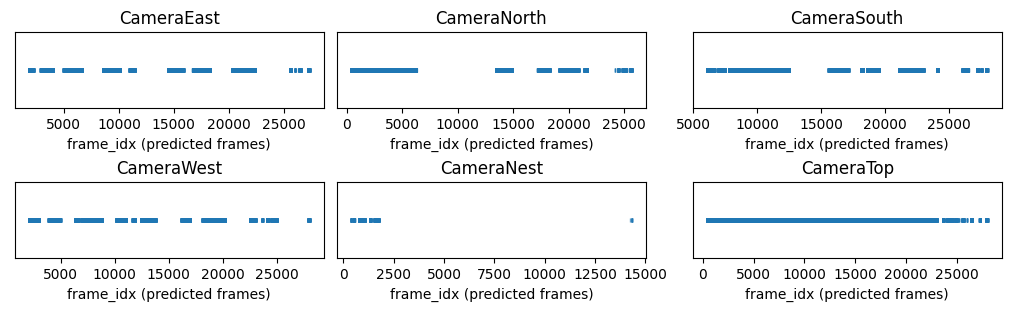

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(10, 3), constrained_layout=True)
axes = axes.ravel()

for ax, cam in zip(axes, CAMERAS):
    f = frames_df[frames_df["camera"] == cam]
    if len(f) == 0:
        ax.set_title(cam + " (no data)")
        ax.axis("off")
        continue

    idxs = np.sort(f["frame_idx"].unique())
    ax.plot(idxs, np.ones_like(idxs), "|", markersize=3, alpha=0.6)
    ax.set_title(cam)
    ax.set_yticks([])
    ax.set_xlabel("frame_idx (predicted frames)")

plt.show()

### Confidence Score of Instance (min of all 4 corners)

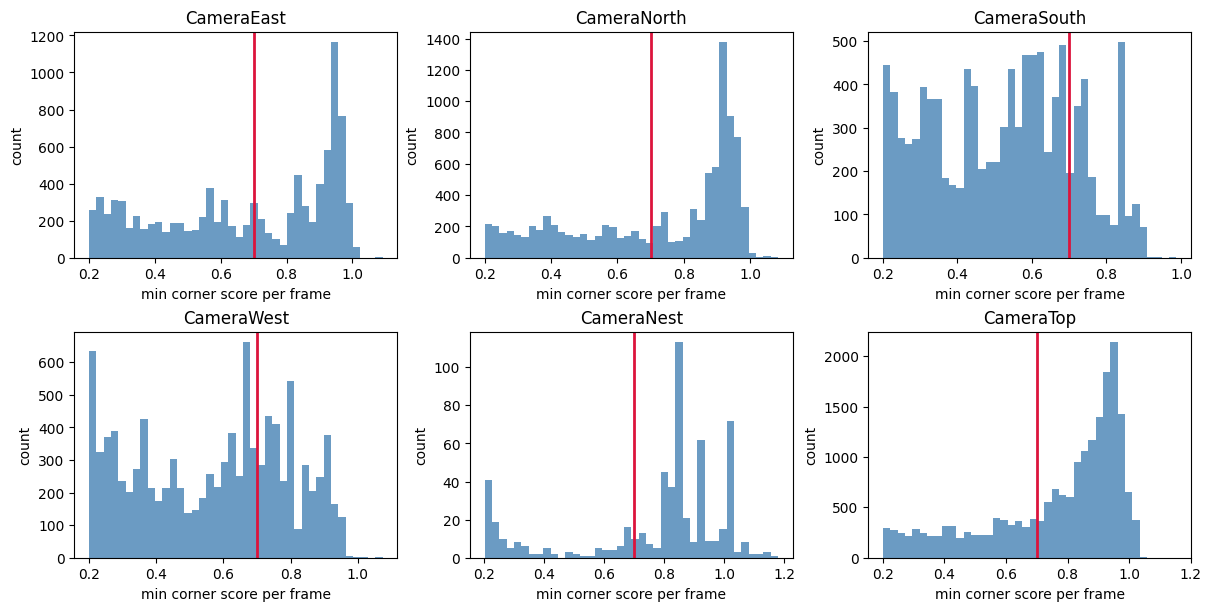

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
axes = axes.ravel()

for ax, cam in zip(axes, CAMERAS):
    f = frames_df[frames_df["camera"] == cam]
    if len(f) == 0:
        ax.set_title(cam + " (no data)")
        ax.axis("off")
        continue

    ax.hist(f["min_score"], bins=40, alpha=0.8, color="steelblue")
    ax.axvline(CONF_THRESH, color="crimson", linewidth=2, label="threshold")
    ax.set_title(cam)
    ax.set_xlabel("min corner score per frame")
    ax.set_ylabel("count")

plt.show()

### Per corner score distributions

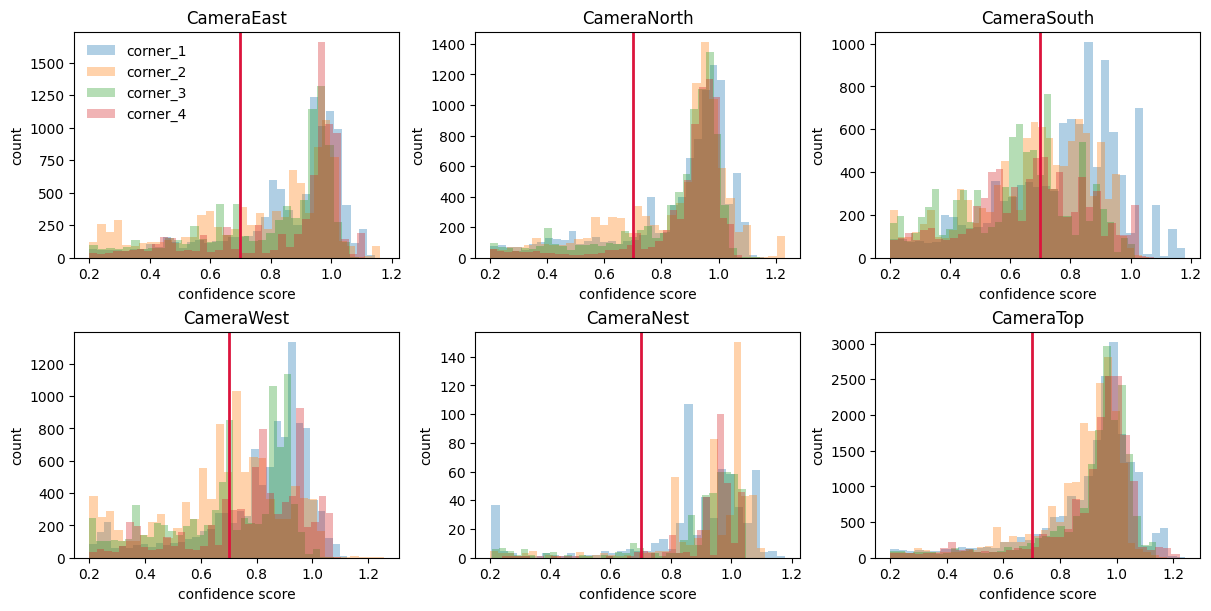

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
axes = axes.ravel()

colors = {
    "corner_1": "#1f77b4",
    "corner_2": "#ff7f0e",
    "corner_3": "#2ca02c",
    "corner_4": "#d62728",
}

for ax, cam in zip(axes, CAMERAS):
    p = points_df[points_df["camera"] == cam]
    if len(p) == 0:
        ax.set_title(cam + " (no data)")
        ax.axis("off")
        continue

    for node in NODE_ORDER:
        s = p.loc[p["node_name"] == node, "score"].dropna()
        if len(s) == 0:
            continue
        ax.hist(s, bins=35, alpha=0.35, label=node, color=colors[node])

    ax.axvline(CONF_THRESH, color="crimson", linewidth=2)
    ax.set_title(cam)
    ax.set_xlabel("confidence score")
    ax.set_ylabel("count")

axes[0].legend(frameon=False, loc="upper left")
plt.show()

### Label placement and confidence score heatmap

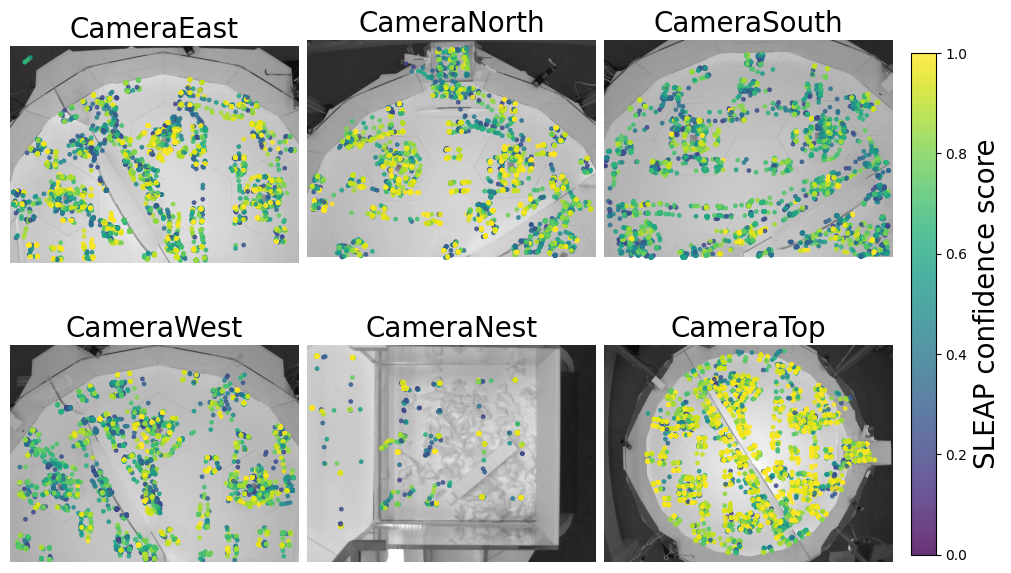

In [11]:
# Heatmap-style scatter: corner locations colored by confidence score (per camera)
fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
axes = axes.ravel()

vmin, vmax = 0.0, 1.0  # SLEAP scores are typically in [0, 1]
cmap = "viridis"

for ax, cam in zip(axes, CAMERAS):
    labels = labels_by_cam[cam]
    v = labels.videos[0]
    video_path = Path(v.filename)

    if not video_path.exists():
        video_path = build_video_path(cam)

    try:
        frame0_rgb = bgr_to_rgb(read_frame(video_path, 0))
    except Exception:
        ax.set_title(cam + " (frame read failed)")
        ax.axis("off")
        continue

    ax.imshow(frame0_rgb)

    p = points_df[points_df["camera"] == cam]
    if len(p) > 0:
        # sample for speed if huge
        p_plot = p.sample(n=min(8000, len(p)), random_state=0)
        sc = ax.scatter(
            p_plot["x"], p_plot["y"],
            c=p_plot["score"],
            s=6,
            alpha=0.8,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
    else:
        sc = None

    ax.set_title(cam, fontsize = 20)
    ax.axis("off")

# One shared colorbar for all subplots
if sc is not None:
    cbar = fig.colorbar(sc, ax=axes, shrink=0.85, pad=0.02)
    cbar.set_label("SLEAP confidence score", fontsize = 20)

plt.show()

### Given threshold, number of labels acceptable

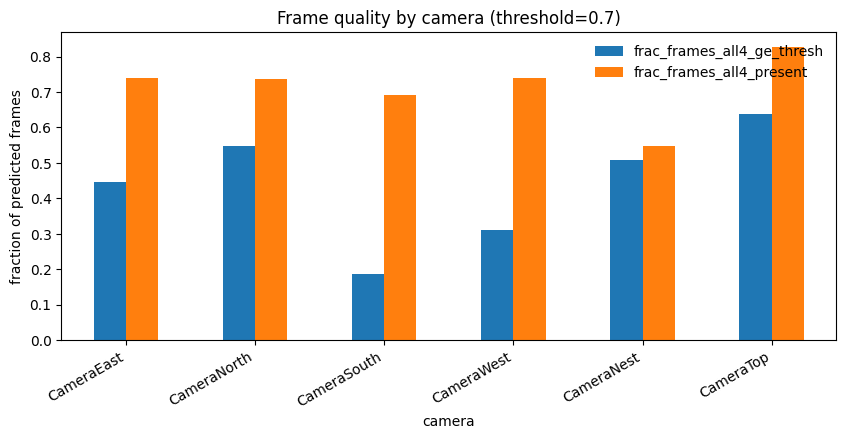

In [12]:
kpi = summary_df[["camera", "frac_frames_all4_ge_thresh", "frac_frames_all4_present"]].copy()
kpi = kpi.set_index("camera")

ax = kpi.plot(kind="bar", figsize=(10, 4))
ax.set_ylabel("fraction of predicted frames")
ax.set_title(f"Frame quality by camera (threshold={CONF_THRESH})")
ax.legend(frameon=False)
plt.xticks(rotation=30, ha="right")
plt.show()